In [41]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df=pd.read_csv(r"C:\Users\anant\Desktop\Car_sales.csv")

In [43]:
df.head()

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         157 non-null    object 
 1   Model                157 non-null    object 
 2   Sales_in_thousands   157 non-null    float64
 3   __year_resale_value  121 non-null    float64
 4   Vehicle_type         157 non-null    object 
 5   Price_in_thousands   155 non-null    float64
 6   Engine_size          156 non-null    float64
 7   Horsepower           156 non-null    float64
 8   Wheelbase            156 non-null    float64
 9   Width                156 non-null    float64
 10  Length               156 non-null    float64
 11  Curb_weight          155 non-null    float64
 12  Fuel_capacity        156 non-null    float64
 13  Fuel_efficiency      154 non-null    float64
 14  Latest_Launch        157 non-null    object 
 15  Power_perf_factor    155 non-null    flo

In [45]:
df.isnull().sum()

Manufacturer            0
Model                   0
Sales_in_thousands      0
__year_resale_value    36
Vehicle_type            0
Price_in_thousands      2
Engine_size             1
Horsepower              1
Wheelbase               1
Width                   1
Length                  1
Curb_weight             2
Fuel_capacity           1
Fuel_efficiency         3
Latest_Launch           0
Power_perf_factor       2
dtype: int64

In [46]:
df1=df.dropna()

In [47]:
df1.isnull().sum()

Manufacturer           0
Model                  0
Sales_in_thousands     0
__year_resale_value    0
Vehicle_type           0
Price_in_thousands     0
Engine_size            0
Horsepower             0
Wheelbase              0
Width                  0
Length                 0
Curb_weight            0
Fuel_capacity          0
Fuel_efficiency        0
Latest_Launch          0
Power_perf_factor      0
dtype: int64

In [48]:
df1["Vehicle_type"].value_counts()

Vehicle_type
Passenger    88
Car          29
Name: count, dtype: int64

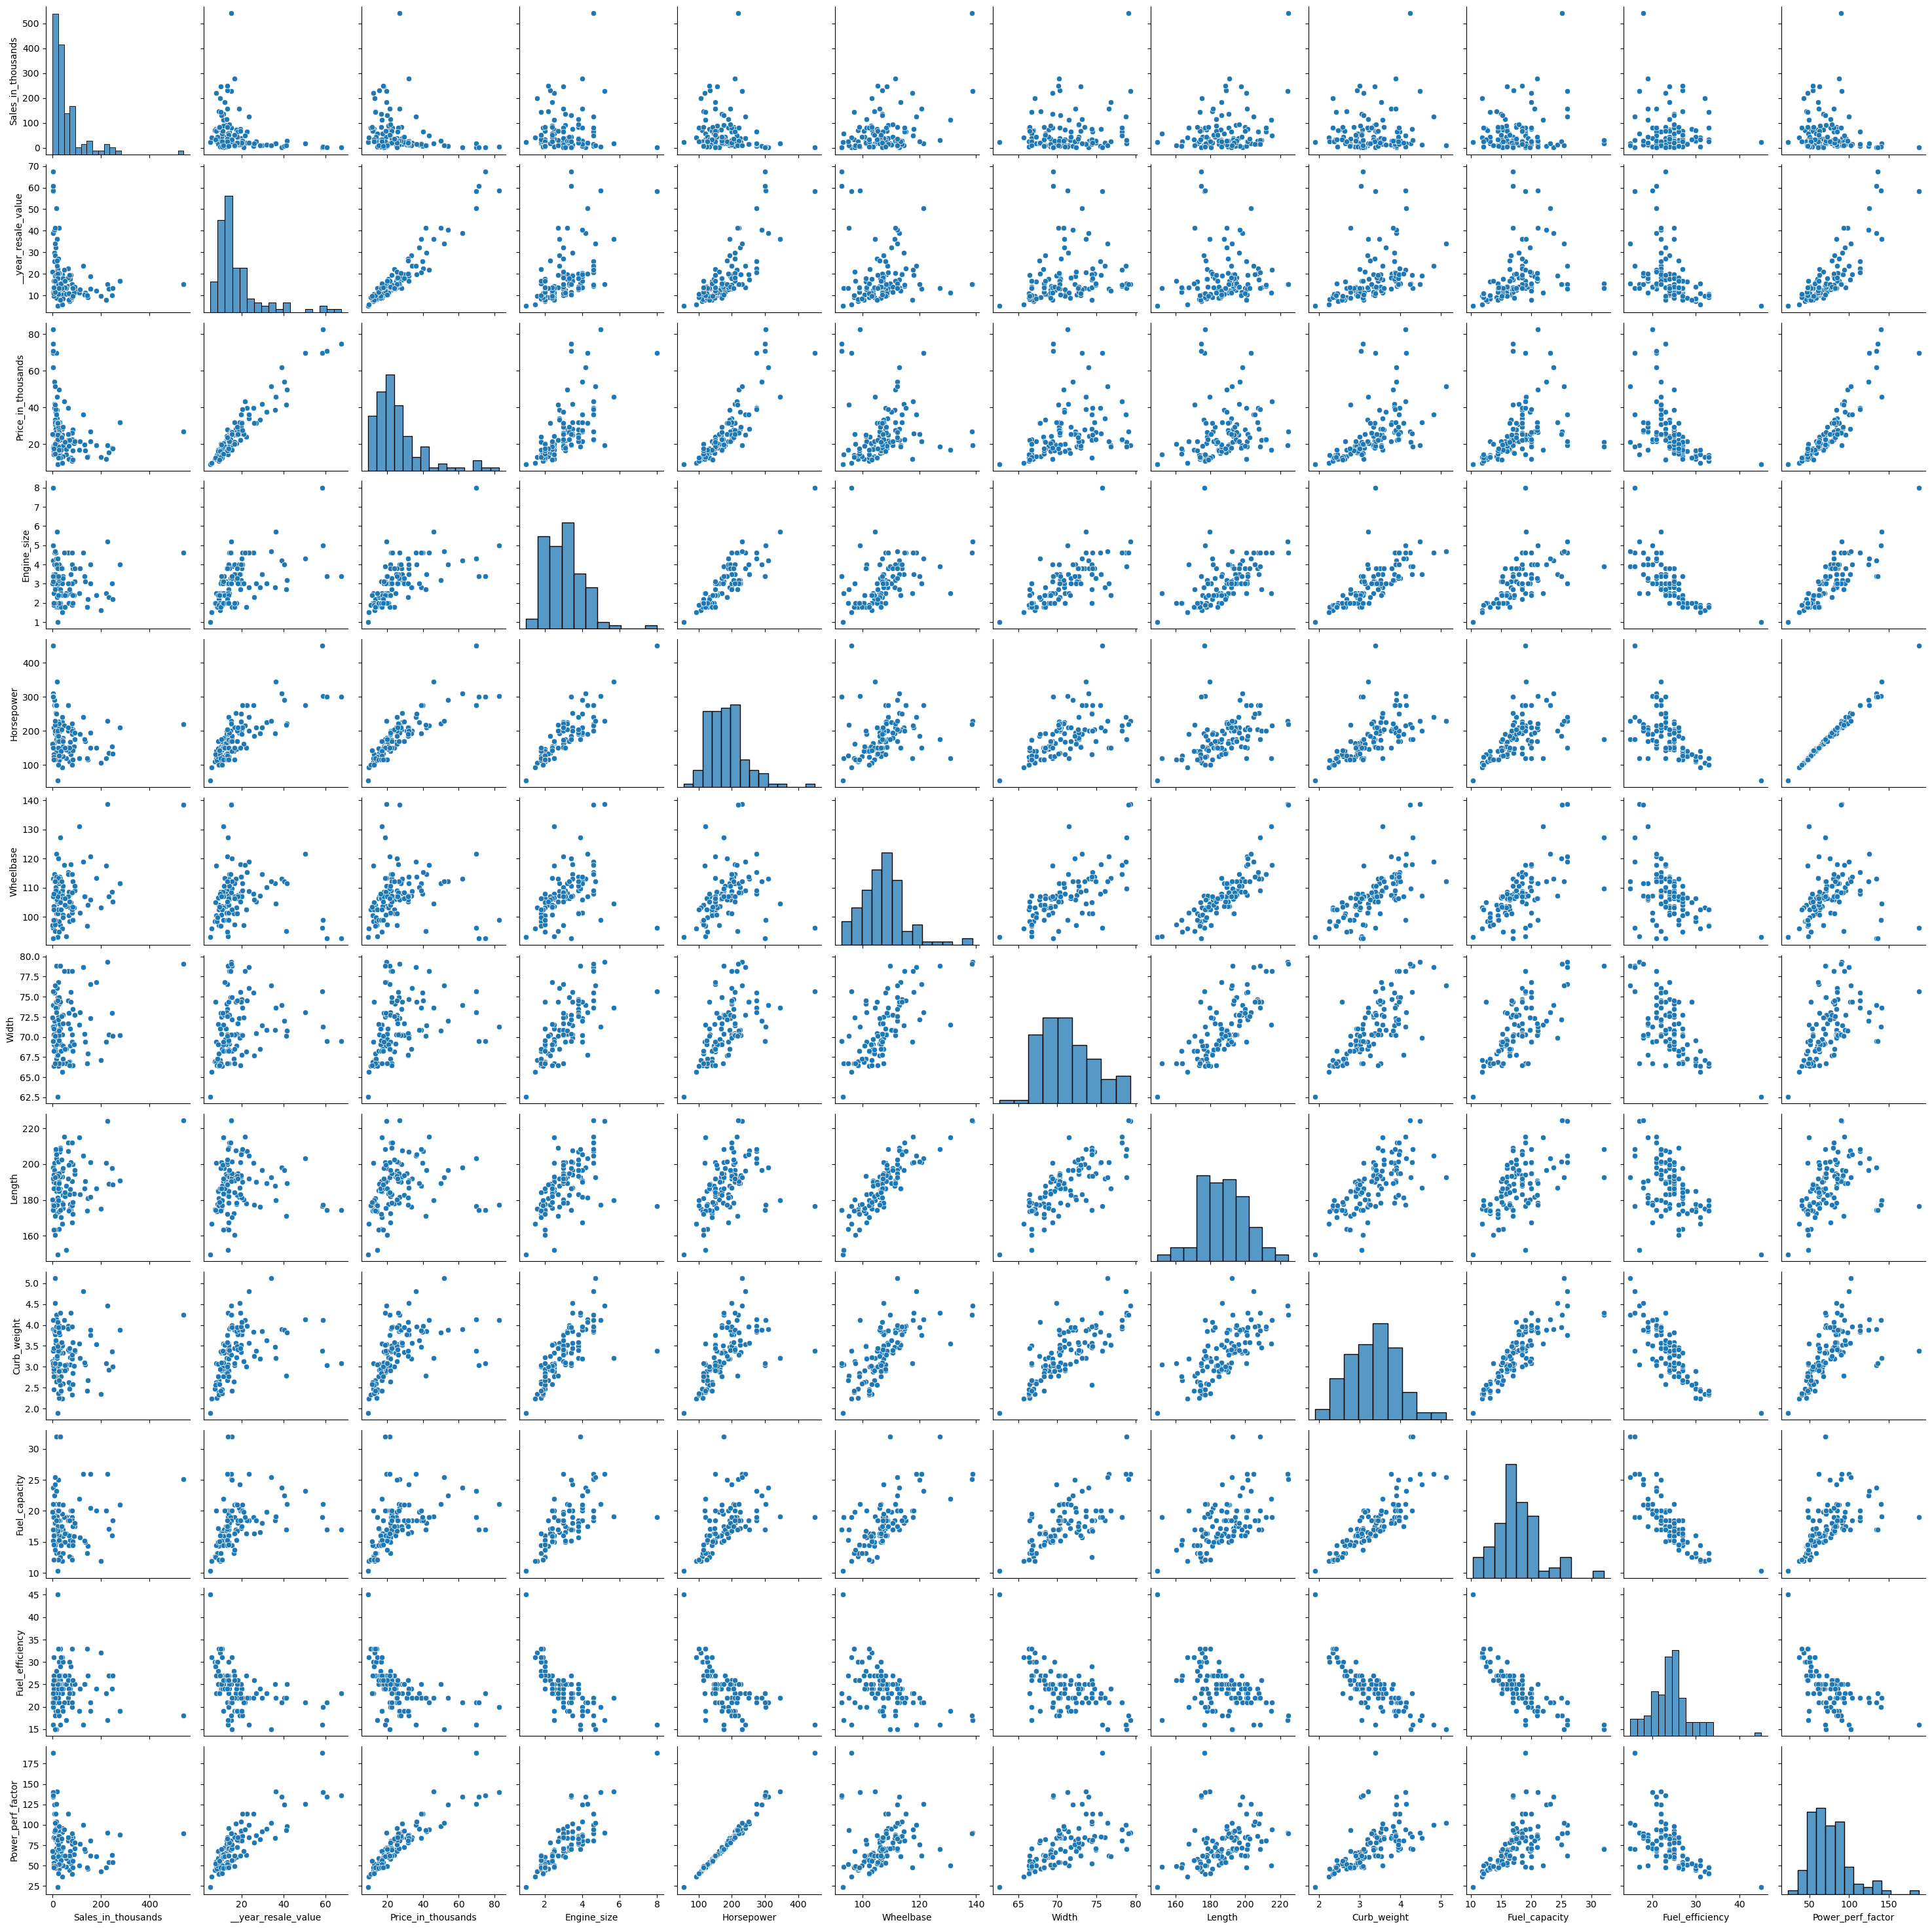

In [49]:
sns.pairplot(df1)
plt.show()

In [50]:
#here we need to find to find to the correlation between the dependent  and independent variable

In [51]:
target = 'Price_in_thousands'
features = [
    'Power_perf_factor',
    'Fuel_efficiency',
    'Curb_weight',
    'Fuel_capacity',
    'Width',
    'Horsepower',
    '__year_resale_value',
    'Engine_size'
]


In [52]:
correlation = df[features + [target]].corr()[target].sort_values(ascending=False)
print(correlation)


Price_in_thousands     1.000000
__year_resale_value    0.953840
Power_perf_factor      0.897945
Horsepower             0.839744
Engine_size            0.626875
Curb_weight            0.526224
Fuel_capacity          0.423282
Width                  0.329136
Fuel_efficiency       -0.492157
Name: Price_in_thousands, dtype: float64


In [53]:
#Our target variable is Price_in_thousands and other are independent variable above 0.5 is comsiders as independent variable 

In [54]:
#now we need to preprocess the necessary colums
#check duplicate values

In [55]:

# Columns to preprocess
cols = ['Price_in_thousands', '__year_resale_value', 'Power_perf_factor',
        'Horsepower', 'Engine_size', 'Curb_weight']

In [56]:
# 1️⃣ Handle Missing Values: Fill numeric columns with mean
df[cols] = df[cols].fillna(df[cols].mean())

In [57]:
# 2️⃣ Handle Outliers using IQR method for each column
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

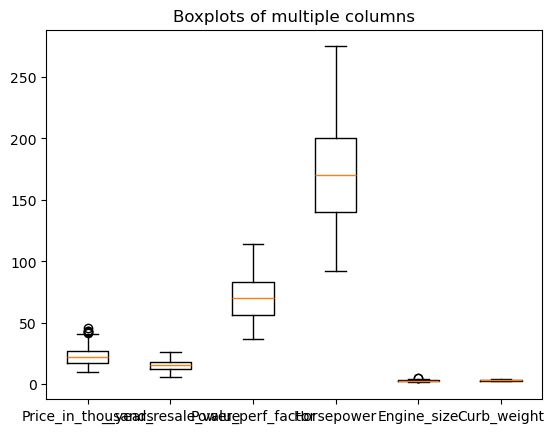

In [58]:
import matplotlib.pyplot as plt
plt.boxplot([df['Price_in_thousands'], df['__year_resale_value'], df['Power_perf_factor'],df['Horsepower'],df['Engine_size'],df['Curb_weight']])
plt.xticks([1, 2, 3,4,5,6], ['Price_in_thousands', '__year_resale_value', 'Power_perf_factor',
        'Horsepower', 'Engine_size', 'Curb_weight'])
plt.title("Boxplots of multiple columns")
plt.show()


In [78]:
#Identify Column Types

In [80]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


In [82]:
print("\nNumeric columns:", numeric_cols)
print("Categorical columns:", cat_cols)



Numeric columns: ['Sales_in_thousands', '__year_resale_value', 'Price_in_thousands', 'Engine_size', 'Horsepower', 'Wheelbase', 'Width', 'Length', 'Curb_weight', 'Fuel_capacity', 'Fuel_efficiency', 'Power_perf_factor']
Categorical columns: ['Manufacturer', 'Model', 'Vehicle_type', 'Latest_Launch']


In [84]:
#Applying Linear Regression

In [86]:
from sklearn.linear_model import LinearRegression

In [88]:
model = LinearRegression()
# we can take Hourse power (independent) vs Price in thousands (dependent)

In [90]:
train_model = model.fit(df[["Horsepower"]], df["Sales_in_thousands"])#X=train data, y=target variable

In [96]:
y_pred = model.predict([[150]])

C:\Users\anant\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [98]:
print("price for",y_pred)

price for [62.95180778]
